# data modeling & model seletcion

Goal:
Predict media coverage (coverage_per_day) based on:
- Crisis severity (people_affected, fund_required, crisis_days)
- Media framing (humanitarian, geopolitical, economic, legal)

Objective:
Understand which factors influence media attention.

In [43]:
import pandas as pd

df = pd.read_csv(r"C:\Users\nikhi\OneDrive\Documents\Data science project\IDS_Project\data\processed\cleaned_model_data.csv")

df.head()

,crisis_id,raw_coverage,fund_required,people_affected,crisis_days,top3_outlet_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian
0,1,8302,3.04,22.9,1287,0.211033,0.000000,0.000000,0.00000
1,2,349,1.50,7.8,5701,0.355301,0.000000,0.000000,0.00000
2,3,1580,3.23,21.2,1075,0.453797,0.000000,0.000000,0.00000
3,4,1511,2.00,10.0,1560,0.551952,0.000000,0.000000,0.00000
4,5,29020,4.00,3.3,496,0.173983,0.014625,0.212684,0.40117


##Quick Exploration Before Modeling

In [44]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   crisis_id                   10 non-null     int64  
 1   raw_coverage                10 non-null     int64  
 2   fund_required               10 non-null     float64
 3   people_affected             10 non-null     float64
 4   crisis_days                 10 non-null     int64  
 5   top3_outlet_ratio           10 non-null     float64
 6   framing_ratio_economic      10 non-null     float64
 7   framing_ratio_geopolitical  10 non-null     float64
 8   framing_ratio_humanitarian  10 non-null     float64
dtypes: float64(6), int64(3)
memory usage: 852.0 bytes


,crisis_id,raw_coverage,fund_required,people_affected,crisis_days,top3_outlet_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,7832.200000,3.955000,16.440000,2355.500000,0.338497,0.005329,0.053729,0.064069
std,3.02765,9909.340081,3.041956,8.051528,1891.970769,0.124151,0.012583,0.116303,0.140340
min,1.00000,349.000000,1.100000,3.300000,496.000000,0.173983,0.000000,0.000000,0.000000
25%,3.25000,1622.250000,2.125000,10.675000,1082.000000,0.221190,0.000000,0.000000,0.000000
50%,5.50000,1914.500000,3.135000,18.100000,1423.500000,0.356566,0.000000,0.000000,0.000000
75%,7.75000,9982.000000,3.830000,20.875000,3546.750000,0.413716,0.000000,0.000000,0.000000
max,10.00000,29020.000000,10.280000,30.400000,5701.000000,0.551952,0.038667,0.324609,0.401170


distributions of data

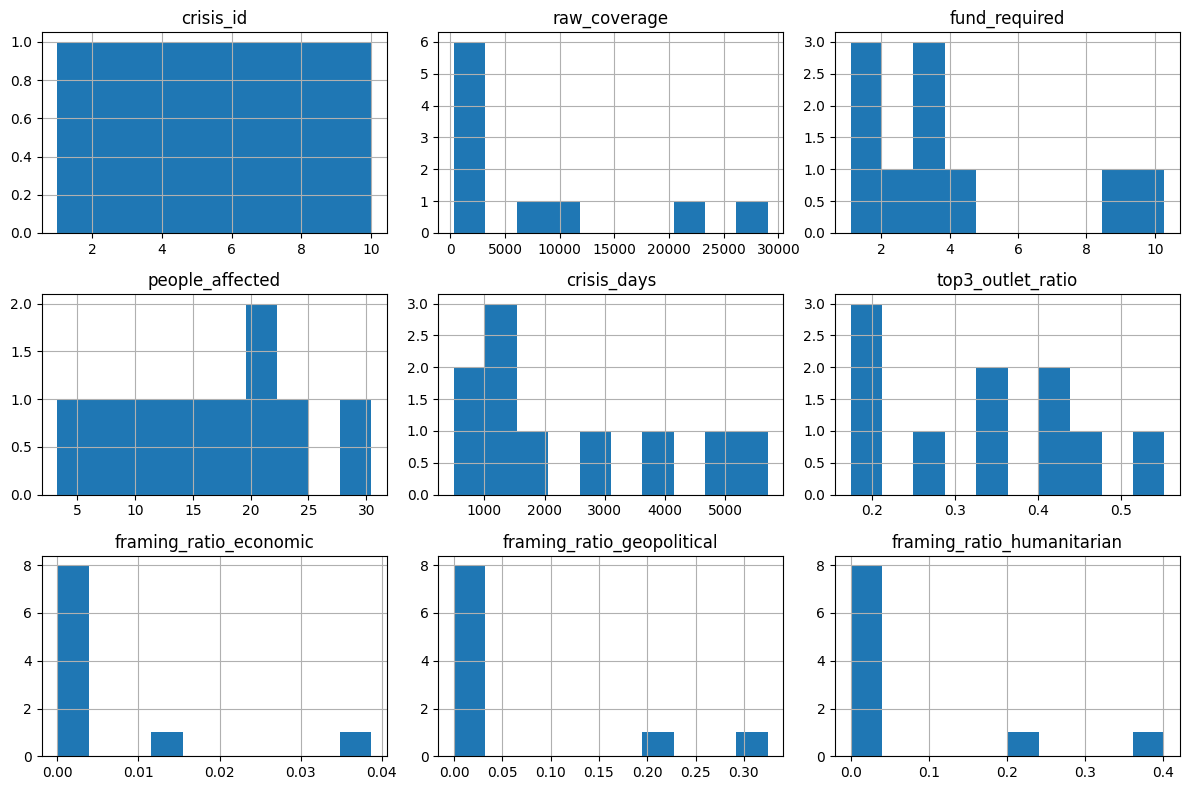

In [45]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

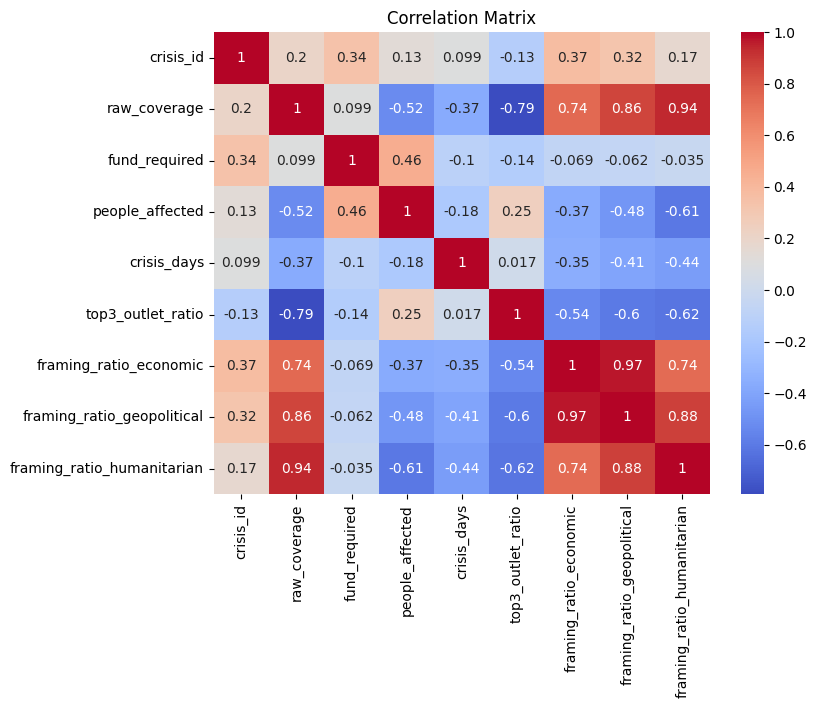

In [46]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [47]:
features = [
    "people_affected",
    "fund_required",
    "crisis_days",
    "framing_ratio_humanitarian",
    "framing_ratio_geopolitical",
    "framing_ratio_economic",
]
target = "raw_coverage"

In [48]:
X = df[features]
y = df[target]

# Model Selection

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [49]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV R2 scores: [-2.90519583e+00 -6.49326573e+03  8.15796884e-01 -1.67557530e+00
  9.12770120e-01]
Mean CV R2: -1299.2235865964944


In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name} Performance:")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R²: {r2:.3f}")
    print("-"*30)

In [33]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")

Linear Regression Performance:
RMSE: 4882.106
MAE: 4414.238
R²: 0.786
------------------------------


In [34]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

evaluate_model(y_test, y_pred_dt, "Decision Tree")

Decision Tree Performance:
RMSE: 8982.028
MAE: 8886.500
R²: 0.275
------------------------------


In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate_model(y_test, y_pred_rf, "Random Forest")

Random Forest Performance:
RMSE: 7927.406
MAE: 7920.650
R²: 0.435
------------------------------


## Compare model performances

In [36]:
results = pd.DataFrame({
    "Model": ["Linear", "Decision Tree", "Random Forest"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

print(results)

           Model        R2
0         Linear  0.785671
1  Decision Tree  0.274538
2  Random Forest  0.434897


In [50]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear", "Decision Tree", "Random Forest"],
    "R2": [0.785, 0.274, 0.435]
})

results

,Model,R2
0,Linear,0.785
1,Decision Tree,0.274
2,Random Forest,0.435


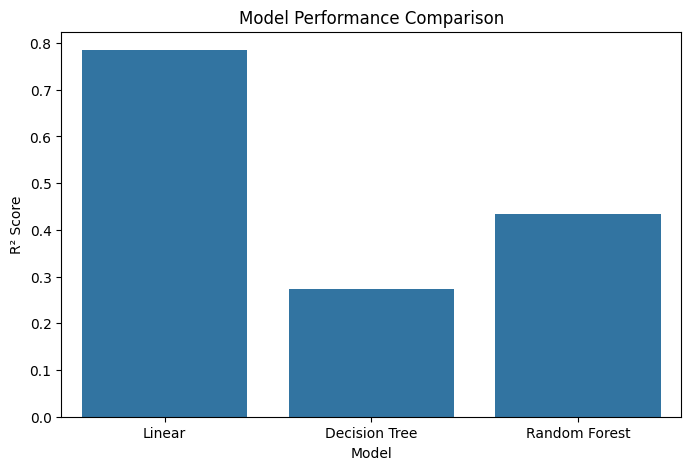

In [53]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="R2")

plt.title("Model Performance Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=0)

plt.show()

### Interpretation:
Linear Regression significantly outperforms both Decision Tree and Random Forest models, achieving the highest R² score (~0.78). This suggests that the relationship between crisis characteristics and media coverage is largely linear. More complex models do not provide additional predictive power, likely due to the small dataset size and limited nonlinear patterns.

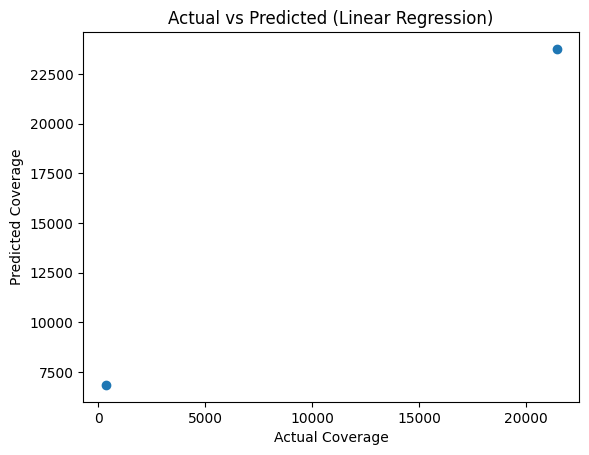

In [38]:
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Coverage")
plt.ylabel("Predicted Coverage")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [41]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(importance)

                      Feature   Coefficient
3  framing_ratio_humanitarian  51239.639552
4  framing_ratio_geopolitical  27165.160209
5      framing_ratio_economic   1867.993930
1               fund_required    377.974697
0             people_affected    -44.561755
2                 crisis_days      1.024968


### Interpretation :

Coefficient = change in coverage_per_day when that feature increases (keeping others constant)

1) Humanitarian framing is the STRONGEST driver: Coefficient: +51,239
    Meaning : Media gives significantly more attention to crises framed in humanitarian terms (e.g., suffering, victims, refugees).

2) Geopolitical framing also strongly increases coverage : Coefficient: +27,165
    Meaning : Crises involving politics, global power, alliances → get more coverage

3) Economic framing comapritively  has very little effect : Coefficient: +1,867
    Economic framing has very little effect

4) People affected is NEGATIVE impacting
    The number of people affected does not positively correlate with media coverage. This suggests that media attention is not purely driven by humanitarian scale.

5) Crisis duration has almost no effect

##### Finally we can deduce from the above that : Media coverage is driven more by how a crisis is framed (humanitarian or geopolitical) rather than how severe it is (people affected or duration) !!

<Axes: title={'center': 'Feature Importance (Linear Regression)'}, ylabel='Feature'>

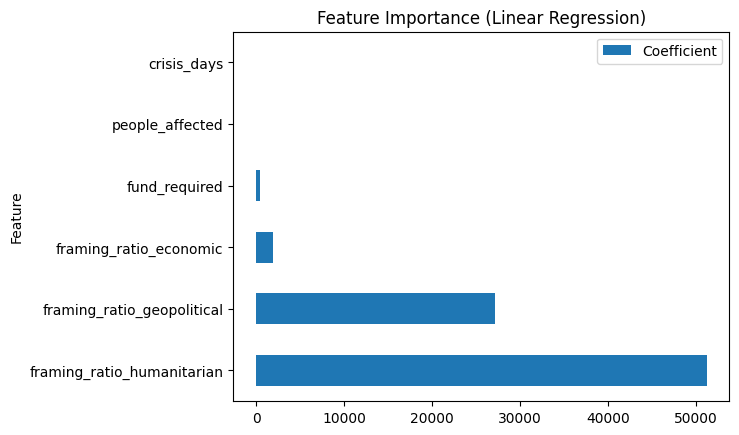

In [42]:
importance.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    title="Feature Importance (Linear Regression)"
)

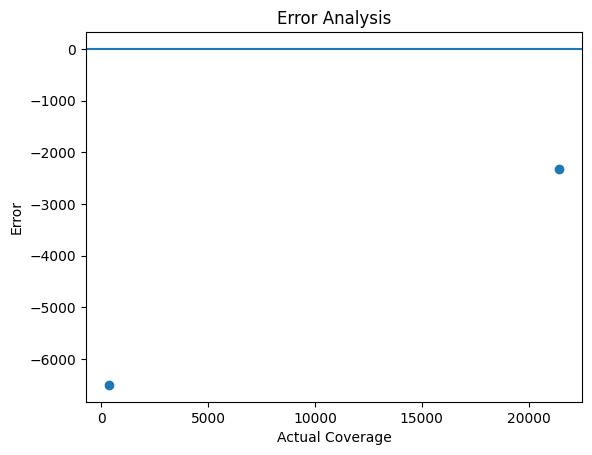

In [51]:
errors = y_test - y_pred_lr

plt.scatter(y_test, errors)
plt.axhline(0)
plt.xlabel("Actual Coverage")
plt.ylabel("Error")
plt.title("Error Analysis")
plt.show()